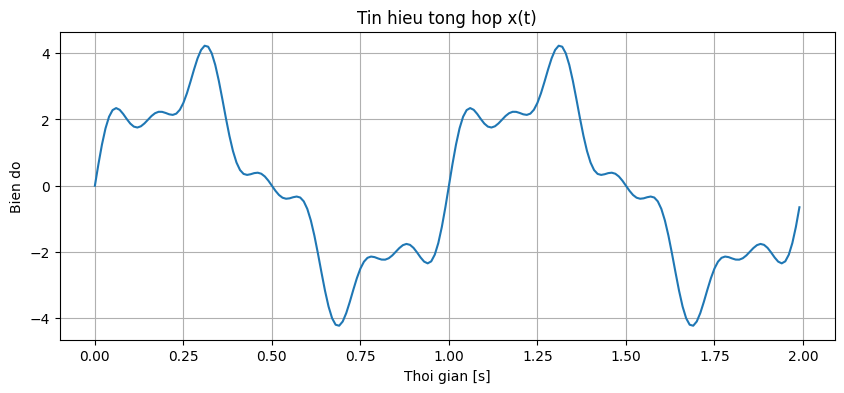

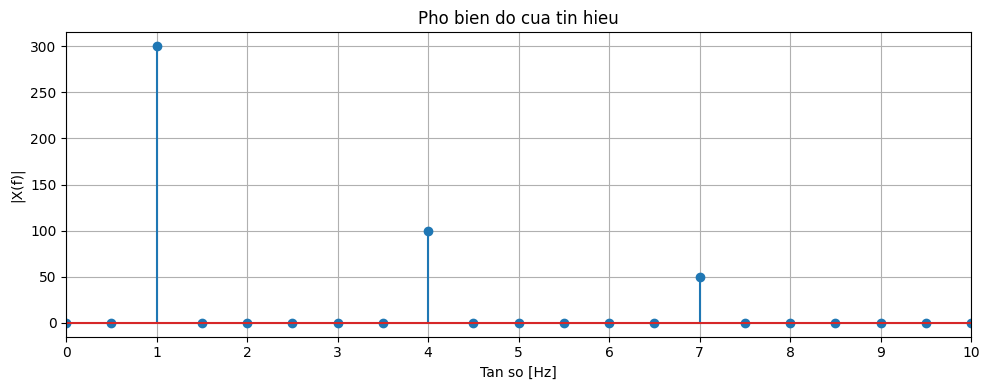

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def dft(x):
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    e = np.exp(-2j * np.pi * k * n / N)
    X = np.dot(e, x)
    return X

def idft(Xk):
    N = len(Xk)
    n = np.arange(N)
    k = n.reshape((N, 1))
    e = np.exp(2j * np.pi * k * n / N)
    x = np.dot(e, Xk) / N
    return x

fs = 100
t = np.arange(0, 2, 1/fs)
x1 = 3 * np.sin(2 * np.pi * 1 * t)
x2 = 1 * np.sin(2 * np.pi * 4 * t)
x3 = 0.5 * np.sin(2 * np.pi * 7 * t)
x = x1 + x2 + x3

plt.figure(figsize=(10, 4))
plt.plot(t, x)
plt.title('Tin hieu tong hop x(t)')
plt.xlabel('Thoi gian [s]')
plt.ylabel('Bien do')
plt.grid(True)

X = dft(x)
N = len(x)

freq = np.arange(N) * fs / N
freq_half = freq[:N // 2 + 1]

amp_half = np.abs(X[:N // 2 + 1])

plt.figure(figsize=(10, 4))
plt.stem(freq_half, amp_half)
plt.title('Pho bien do cua tin hieu')
plt.xlabel('Tan so [Hz]')
plt.ylabel('|X(f)|')
plt.xlim(0, 10)
plt.xticks(np.arange(0, 11, 1))
plt.grid(True)

plt.tight_layout()
plt.show()

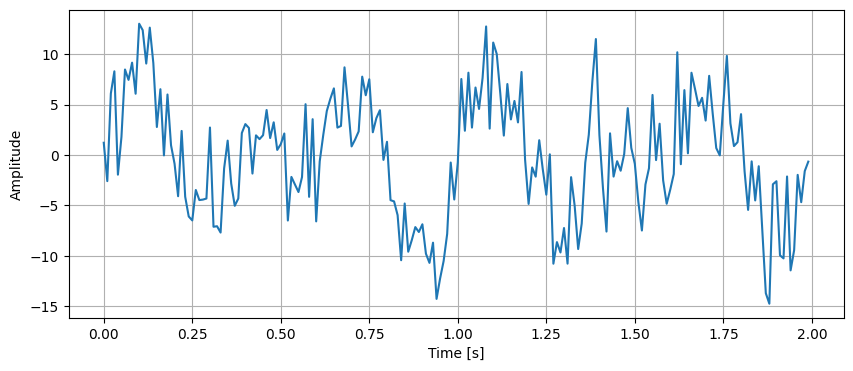

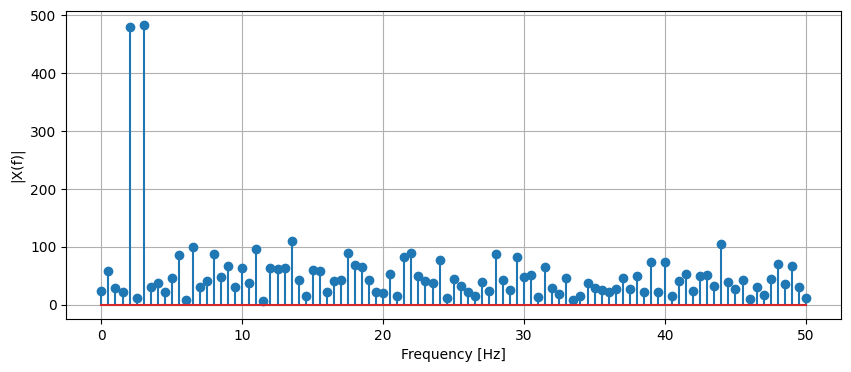

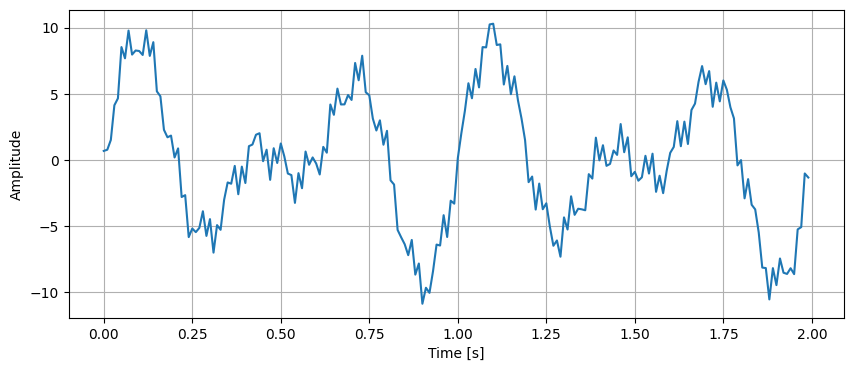

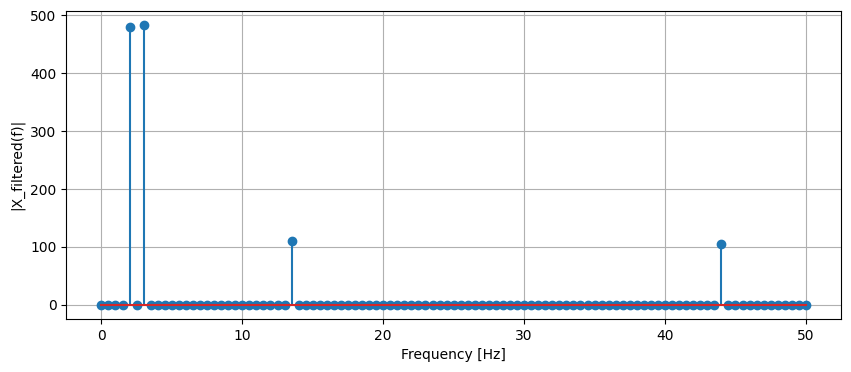

In [3]:
fs = 100
data = np.loadtxt('data/ex2-data.txt')

t = np.arange(len(data)) / fs

plt.figure(figsize=(10, 4))
plt.plot(t, data)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

X_data = dft(data)
N = len(data)

freq = np.arange(N) * fs / N
freq_half = freq[:N // 2 + 1]
amp_half = np.abs(X_data[:N // 2 + 1])

plt.figure(figsize=(10, 4))
plt.stem(freq_half, amp_half)
plt.xlabel('Frequency [Hz]')
plt.ylabel('|X(f)|')
plt.grid(True)
plt.show()

threshold = 100
X_filtered = X_data.copy()
X_filtered[np.abs(X_filtered) < threshold] = 0

filtered_signal = idft(X_filtered)

plt.figure(figsize=(10, 4))
plt.plot(t, filtered_signal.real)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

amp_half_filtered = np.abs(X_filtered[:N // 2 + 1])

plt.figure(figsize=(10, 4))
plt.stem(freq_half, amp_half_filtered)
plt.xlabel('Frequency [Hz]')
plt.ylabel('|X_filtered(f)|')
plt.grid(True)
plt.show()

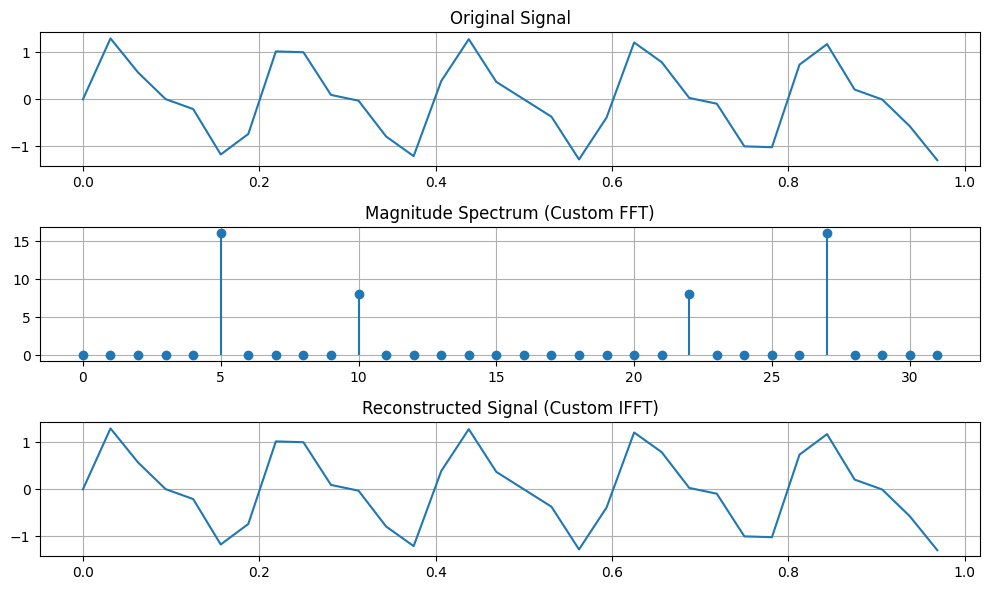

In [4]:
def fft(x):
    N = x.size
    if N <= 1:
        return x
    even = fft(x[::2])
    odd = fft(x[1::2])
    factor = np.exp(-2j * np.pi * np.arange(N) / N)
    term = factor[:N // 2] * odd
    return np.concatenate([even + term, even - term])

def ifft(X):
    N = X.size
    if N <= 1:
        return X
    conjugate_X = np.conjugate(X)
    fft_of_conjugate = fft(conjugate_X)
    result = np.conjugate(fft_of_conjugate) / N
    return result

fs_sample = 32
t_sample = np.arange(0, 1, 1/fs_sample)
signal_sample = (np.sin(2 * np.pi * 5 * t_sample) +
                 0.5 * np.sin(2 * np.pi * 10 * t_sample))

fft_custom = fft(signal_sample)
reconstructed_signal = ifft(fft_custom)

plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.plot(t_sample, signal_sample)
plt.title('Original Signal')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.stem(np.abs(fft_custom), basefmt=" ")
plt.title('Magnitude Spectrum (Custom FFT)')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t_sample, reconstructed_signal.real)
plt.title('Reconstructed Signal (Custom IFFT)')
plt.grid(True)

plt.tight_layout()
plt.show()